# Preprocessing Pipeline -- WELFake Dataset

This notebook applies a structured preprocessing pipeline to the raw
WELFake dataset before model training. The steps are designed to address
the data quality issues identified in the EDA notebook:

- 558 null titles and 783 null text entries
- 9,415 duplicate text entries (13.05% of the dataset)
- Non-ASCII characters in 48.6% of articles
- Extreme outliers in article length

Each step is logged with before and after row counts to maintain
full transparency over what is changed and why.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add parent directory to path so src/ modules can be imported
sys.path.append('..')

from src.preprocess import (
    load_data, standardize_nulls, combine_title_text,
    deduplicate, apply_cleaning, split_data,
    save_splits, run_pipeline
)
from src.visualize import (
    plot_before_after_dedup,
    plot_length_after_cleaning,
    plot_split_distribution
)

# Set consistent plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Define project paths
RAW_DATA_PATH = '../data/raw/WELFake_Dataset.csv'
PROCESSED_DIR = '../data/processed/'
FIGURES_DIR   = '../outputs/figures/preprocessing/'

## Step 1 -- Load Raw Data

The raw dataset contains 72,134 articles across four columns.
The first column is an unnamed index artifact from the original
CSV export and is dropped immediately.

In [2]:
df = load_data(RAW_DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Dtypes:\n{df.dtypes}')
df.head(3)

Loaded 72,134 rows from ../data/raw/WELFake_Dataset.csv
Shape: (72134, 3)
Columns: ['title', 'text', 'label']
Dtypes:
title    object
text     object
label     int64
dtype: object


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


## Step 2 -- Standardize Null Values

Whitespace-only strings are not detected as null by default.
This step strips all text fields and replaces empty strings
with NaN so that all missing value handling is consistent.

In [3]:
df = standardize_nulls(df)
print('Null counts after standardization:')
print(df[['title', 'text', 'label']].isnull().sum())

Null counts after standardization:
title    558
text     783
label      0
dtype: int64


## Step 3 -- Combine Title and Text

A single content column is created by concatenating the title
and text fields. This ensures that articles with missing text
still contribute their title to the model, and vice versa.
Rows where both fields are null are removed entirely.

In [4]:
df = combine_title_text(df)
print(f'Shape after combining: {df.shape}')
print('\nSample content field:')
print(df['content'].iloc[0][:200])

combine_title_text: dropped 0 rows where both title and text were null.
Shape after combining: (72134, 4)

Sample content field:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #F


## Step 4 -- Deduplication

The EDA identified 9,415 duplicate text entries representing
13.05% of the total dataset. Deduplication is performed here,
before the train/test split, to prevent any duplicate article
from appearing in both the training and test sets, which would
cause data leakage and artificially inflate model accuracy.

Removed 9,429 duplicate rows. Remaining: 62,705


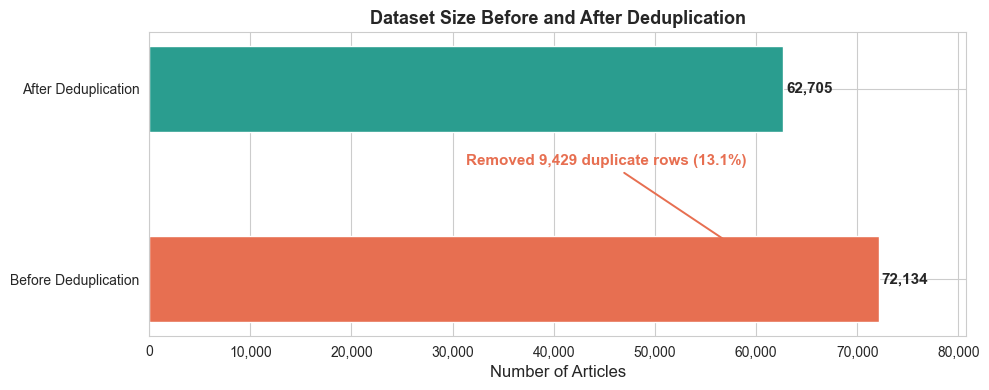

In [5]:
rows_before_dedup = len(df)
df, n_removed = deduplicate(df)
rows_after_dedup = len(df)

# Generate and save before vs after dedup plot
fig = plot_before_after_dedup(
    rows_before_dedup, rows_after_dedup,
    save_path=os.path.join(FIGURES_DIR, '07_before_after_dedup.png')
)
plt.show()

## Step 5 -- Text Cleaning

The content column is cleaned using a sequence of normalization
steps. The order matters: URLs are removed before punctuation
stripping so that special characters in URLs do not produce
noise tokens.

Stop words are intentionally preserved at this stage. The
TF-IDF vectorizer in the feature engineering notebook will
handle stop word removal through its min_df and max_df
parameters, which is more principled than a static stop
word list.

In [6]:
# Show a before sample so the cleaning effect is visible
print('Before cleaning (first article, first 300 chars):')
print(df['content'].iloc[0][:300])
print()

df = apply_cleaning(df)

print('After cleaning (first article, first 300 chars):')
print(df['content'].iloc[0][:300])
print(f'\nShape after cleaning: {df.shape}')

Before cleaning (first article, first 300 chars):
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cop



Dropped 45 rows with content under 10 characters.
After cleaning (first article, first 300 chars):
law enforcement on high alert following threats against cops and whites on 911by blacklivesmatter and fyf911 terrorists video no comment is expected from barack obama members of the fyf911 or fukyoflag and blacklivesmatter movements called for the lynching and hanging of white people and cops they e

Shape after cleaning: (62660, 4)


## Step 6 -- Text Length Distribution After Cleaning

Examining the word count distribution after cleaning confirms
that the data is suitable for sequence modeling. This plot
informs the choice of max sequence length for the BiLSTM model.

/Users/siddhishnirgude/Documents/Personal/USA/Semester 4 MSU/Project Applied ML/notebooks/../src/visualize.py:355: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


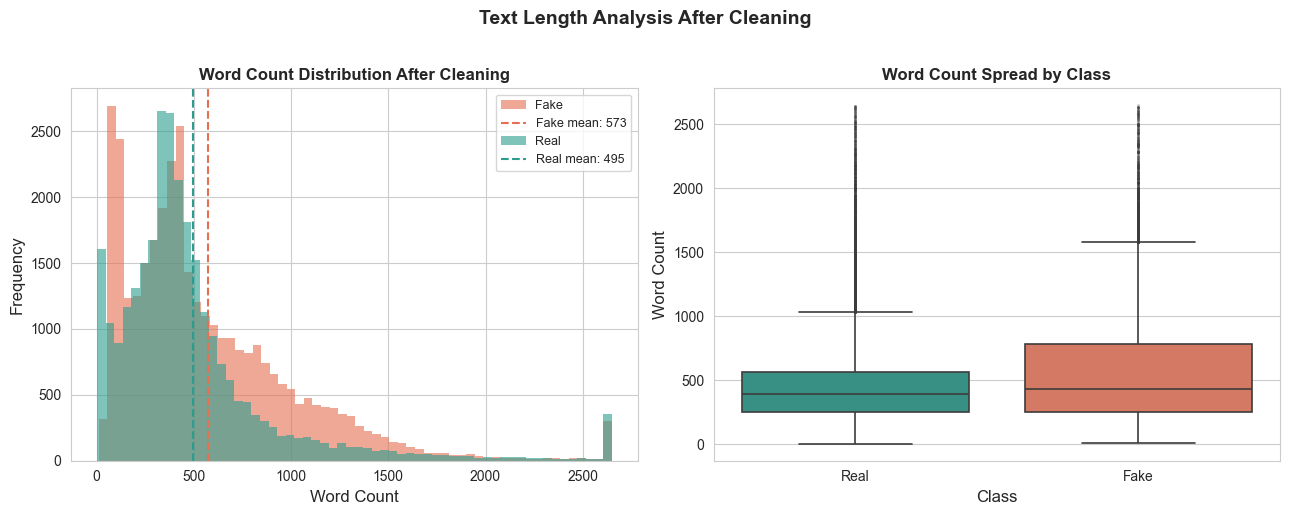

Word count stats:
count    62660.0
mean       555.2
std        600.1
min          2.0
25%        252.0
50%        414.0
75%        686.0
max      24136.0
Name: word_count, dtype: float64


In [7]:
df['word_count'] = df['content'].str.split().str.len()

fig = plot_length_after_cleaning(
    df,
    save_path=os.path.join(FIGURES_DIR, '08_length_after_cleaning.png')
)
plt.show()

print('Word count stats:')
print(df['word_count'].describe().round(1))

## Step 7 -- Train, Validation, and Test Split

The cleaned dataset is split into three stratified sets.
Stratification ensures that the class ratio (48.6% fake /
51.4% real) is preserved in every split. The random state
is fixed at 42 for full reproducibility.

Split proportions:
- Train: 70%
- Validation: 15%
- Test: 15%

Train: 43,862 rows | Fake=55.25%  Real=44.75%
Val  : 9,399 rows | Fake=55.25%  Real=44.75%
Test : 9,399 rows | Fake=55.25%  Real=44.75%


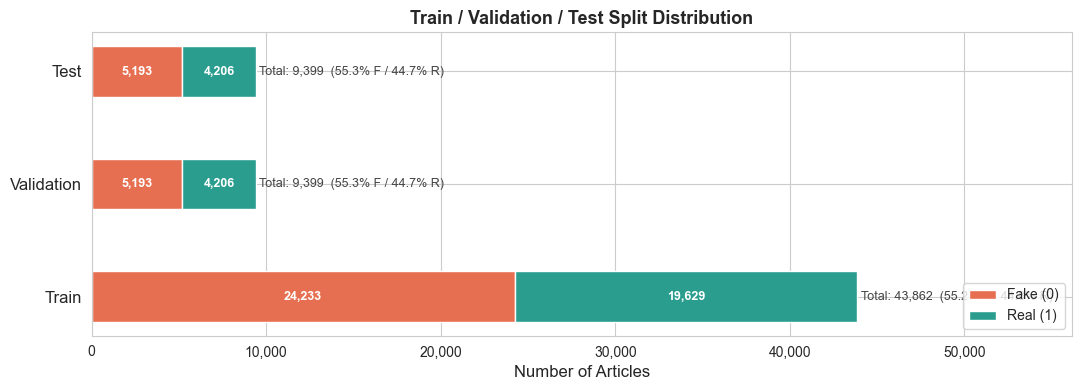

In [8]:
train_df, val_df, test_df = split_data(df)

# Generate and save split distribution plot
fig = plot_split_distribution(
    train_df, val_df, test_df,
    save_path=os.path.join(FIGURES_DIR, '09_split_distribution.png')
)
plt.show()

## Step 8 -- Save Processed Splits

The three splits are saved as CSV files in data/processed/.
These files are the single source of truth for all subsequent
modeling notebooks. No further preprocessing should be applied
to these files -- they are ready for feature engineering.

In [9]:
save_splits(train_df, val_df, test_df, PROCESSED_DIR)

# Final verification
print('\nVerification -- saved file sizes:')
for fname in ['train_clean.csv', 'val_clean.csv', 'test_clean.csv']:
    fpath = os.path.join(PROCESSED_DIR, fname)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f'  {fname}: {size_mb:.2f} MB')

Saved train_clean.csv: 43,862 rows -> ../data/processed/train_clean.csv


Saved val_clean.csv: 9,399 rows -> ../data/processed/val_clean.csv


Saved test_clean.csv: 9,399 rows -> ../data/processed/test_clean.csv

Verification -- saved file sizes:
  train_clean.csv: 281.08 MB
  val_clean.csv: 59.89 MB
  test_clean.csv: 59.97 MB


## Summary

This section records the final state of the data after
all preprocessing steps have been applied.

In [10]:
print('=' * 55)
print('PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Raw dataset rows      : 72,134')
print(f'After deduplication   : {rows_after_dedup:,}')
print(f'After cleaning        : {len(df):,}')
print(f'Rows dropped total    : {72134 - len(df):,}')
print()
print(f'Train set             : {len(train_df):,} rows')
print(f'Validation set        : {len(val_df):,} rows')
print(f'Test set              : {len(test_df):,} rows')
print()
print('Class balance -- Train :')
print(train_df['label'].value_counts(normalize=True).round(4))
print()
print('Class balance -- Val   :')
print(val_df['label'].value_counts(normalize=True).round(4))
print()
print('Class balance -- Test  :')
print(test_df['label'].value_counts(normalize=True).round(4))
print('=' * 55)

PREPROCESSING SUMMARY
Raw dataset rows      : 72,134
After deduplication   : 62,705
After cleaning        : 62,660
Rows dropped total    : 9,474

Train set             : 43,862 rows
Validation set        : 9,399 rows
Test set              : 9,399 rows

Class balance -- Train :
label
0    0.5525
1    0.4475
Name: proportion, dtype: float64

Class balance -- Val   :
label
0    0.5525
1    0.4475
Name: proportion, dtype: float64

Class balance -- Test  :
label
0    0.5525
1    0.4475
Name: proportion, dtype: float64


## Next Steps

The processed splits are saved in data/processed/ and are
ready for feature engineering in notebook 03_tfidf_baselines.ipynb.

Three feature representations will be built:
1. TF-IDF vectors (word unigrams + bigrams, character n-grams)
2. GloVe 100-dimensional pretrained word embeddings
3. Handcrafted linguistic features (readability, sentiment, style)